## Exploratory Analisys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io

In [2]:
data = pd.read_csv('sensors.csv', sep = ',')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6928 entries, 0 to 6927
Data columns (total 95 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6927 non-null   object 
 1   Total Voltage (V)    6927 non-null   object 
 2   Average Voltage (V)  6927 non-null   float64
 3   sensor 1             6927 non-null   float64
 4   sensor 2             6927 non-null   float64
 5   sensor 3             6927 non-null   float64
 6   sensor 4             6927 non-null   float64
 7   sensor 5             6927 non-null   float64
 8   sensor 6             6927 non-null   float64
 9   sensor 7             6927 non-null   float64
 10  sensor 8             6927 non-null   float64
 11  sensor 9             6927 non-null   float64
 12  sensor 10            6927 non-null   float64
 13  sensor 11            6927 non-null   float64
 14  sensor 12            6927 non-null   float64
 15  sensor 13            6927 non-null   f

In [3]:
#Dropping columns that are not relevant for the model  
data = data.drop(columns = ['Total Voltage (V)', 'Average Voltage (V)'])

#Converting the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


#Checking the first few rows of the updated dataset
data.head(3)

,Date,sensor 1,sensor 2,sensor 3,sensor 4,sensor 5,sensor 6,sensor 7,sensor 8,sensor 9,...,sensor 83,sensor 84,sensor 85,sensor 86,sensor 87,sensor 88,sensor 89,sensor 90,sensor 91,sensor 92
0,2023-04-03 03:00:01,119.121812,115.827723,116.327884,117.658852,117.589612,117.496657,115.859532,114.603809,118.058141,...,115.647812,114.299245,116.471634,115.380364,115.110607,115.910664,117.049984,114.031306,113.770388,115.565692
1,2023-04-03 04:00:01,121.092423,117.628034,118.118468,119.575351,119.504139,119.387818,117.598619,116.261870,119.998991,...,117.329442,115.892439,118.243012,117.071528,116.750911,117.634598,118.956594,115.616289,115.338720,117.255179
2,2023-04-03 05:00:01,121.893561,118.410648,118.866724,120.405980,120.332878,120.213393,118.315624,116.951690,120.807357,...,118.087727,116.615680,119.053043,117.826122,117.492186,118.392878,119.695606,116.356843,116.066697,118.036934


The fig above show when the site shutdown, and thats it's not a good messure to bring to the model

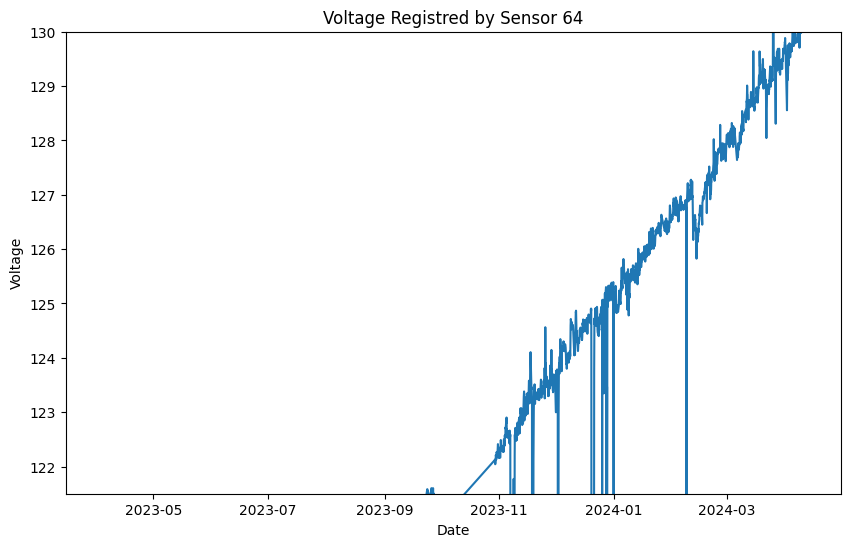

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = data, y='sensor 64', x='Date')
plt.title('Voltage Registred by Sensor 64')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [5]:
data = data[data['sensor 64'] > 121.5 ]
data['sensor 64'].describe()

count    3535.000000
mean      126.045716
std         2.278536
min       121.500961
25%       124.214188
50%       126.007869
75%       127.876224
max       130.398127
Name: sensor 64, dtype: float64

In [6]:
average_s64 = data.groupby(data['Date'].dt.date)['sensor 64'].mean()
average_s64 = average_s64.reset_index()
average_s64.rename(columns={'Date': 'average_daily'}, inplace=True)
average_s64

,average_daily,sensor 64
0,2023-09-23,121.566813
1,2023-09-25,121.581568
2,2023-09-26,121.556520
3,2023-09-27,121.502602
4,2023-10-29,122.075067
...,...,...
163,2024-04-07,129.871961
164,2024-04-08,130.174848
165,2024-04-09,130.113218
166,2024-04-10,130.129586


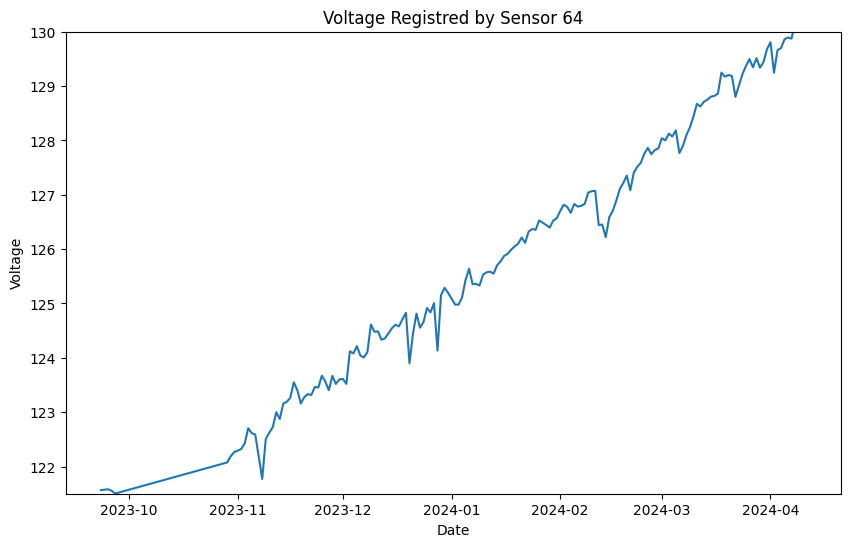

In [7]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = average_s64, x='average_daily', y='sensor 64')
plt.title('Voltage Registred by Sensor 64')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [8]:
average_s64['diff'] = average_s64['sensor 64'].diff()
average_s64.dropna(inplace=True)
average_s64.head(3)

,average_daily,sensor 64,diff
1,2023-09-25,121.581568,0.014755
2,2023-09-26,121.556520,-0.025048
3,2023-09-27,121.502602,-0.053919


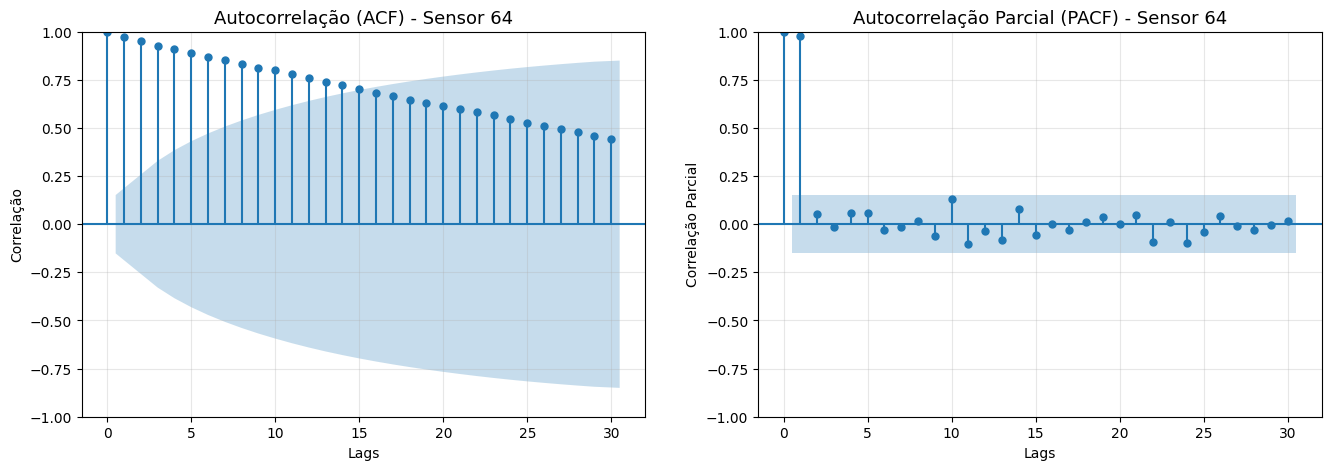

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s64['sensor 64'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Sensor 64', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s64['sensor 64'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Sensor 64', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

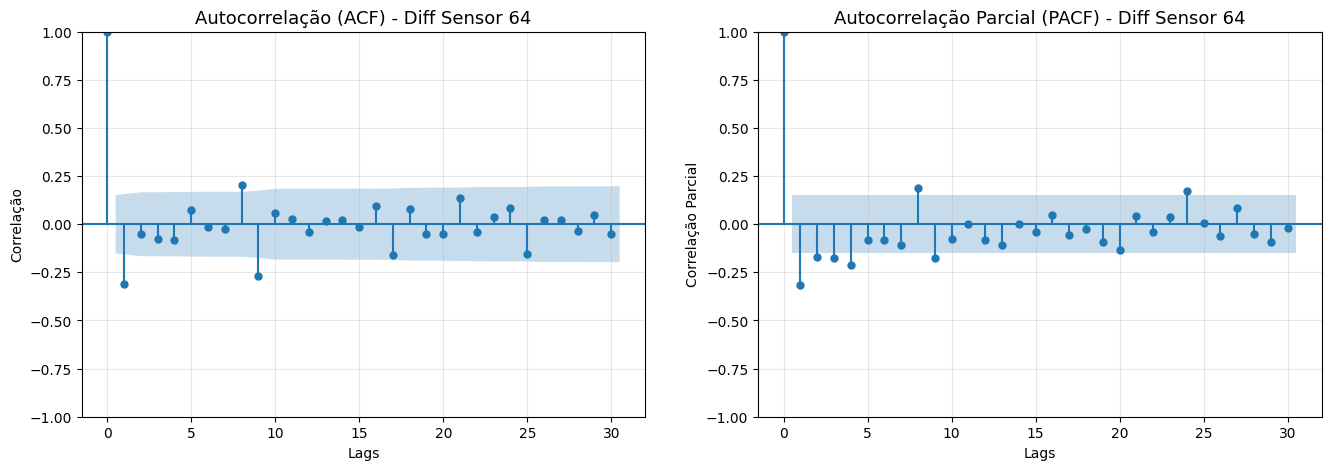

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s64['diff'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Diff Sensor 64', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s64['diff'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Diff Sensor 64', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

## Features

Separating into test and training sets

In [11]:
for i in range(1, 3, 1):
        average_s64[f'shift_{i}'] = average_s64['sensor 64'].shift(i)
average_s64.dropna(inplace=True)

y = average_s64['sensor 64'].values.reshape(-1, 1).astype('float32')
X = average_s64[[f'shift_{i}' for i in range(1, 3)]].values.astype('float32')  # Usando os valores dos 8 dias anteriores como recursos


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) #shuffle=False to maintain the time series order


In [12]:
preview = pd.DataFrame(X_train, columns=[f'shift_{i}' for i in range(1, 3)])
preview.head(3)

,shift_1,shift_2
0,121.556519,121.581566
1,121.502602,121.556519
2,122.075066,121.502602


In [13]:
X.shape, y.shape

((165, 2), (165, 1))

Normalizando dados

In [14]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Evitar datalake

Hiperparâmetros

In [15]:
TAXA_APRENDIZADO = 0.001  # Tamanho do "passo" na otimização (ex: 0.1, 0.01, 0.001)
EPOCAS = 100             # Quantas vezes a rede verá todo o dataset
TAMANHO_LOTE = 3     # Batch size 
tf.keras.utils.set_random_seed(42)

Aplicando o treinamento

In [16]:
#Construção da arquitetura

#Camada de Entrada
model_mlp = Sequential([Dense(12, # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(2,), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation='relu') ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...


#Camada Oculta 1
model_mlp.add(Dense(8, activation='relu'))

#Camada de Saída
model_mlp.add(Dense(1, activation='linear')) # 1 Neurônio nesta camada (Z = W*X + b) --- IGNORE ---, ativação linear para regressão


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=TAXA_APRENDIZADO), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)

#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train, #Indica quais são as bases
    epochs=EPOCAS, batch_size=TAMANHO_LOTE, #O batch_size é a batelada de cada iteração (epoch) que será calculada
    shuffle=False, # Manter a ordem temporal dos dados
    verbose=1 # Mude para 1 se quiser ver o log de cada época
)

c:\Projeto de Manutenção\Maintenance-prediction\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 15683.6426 - mae: 125.2231   
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15593.8828 - mae: 124.8653 
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15514.0928 - mae: 124.5467 
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15405.3076 - mae: 124.1111 
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15227.9463 - mae: 123.3969 
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14978.9590 - mae: 122.3863 
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14646.5117 - mae: 121.0222 
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14181.8027 - mae: 119.0863 
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13526.7207 - mae: 116.2962 
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12663.8145 - mae: 112.5041 
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11599.7891 - mae: 107.6256 
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━

In [17]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.76 KB)

 Trainable params: 149 (596.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 300 (1.18 KB)

In [18]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [ 0.7748982   0.15175164  0.1786556   0.9132501  -0.5524477   0.15466969
  0.25552556 -0.4348051   0.02514203 -0.04736141 -0.22046396 -0.07023454
  0.8903558  -0.10220324  0.3430475   0.64439845 -0.62999946 -0.49402204
 -0.37228662 -0.5676833  -0.6053648   0.23691045  0.8385173  -0.31090704] e o viés: 1.7403


In [19]:
data_min = scaler.data_min_
scale = scaler.scale_

# w = pesos / scale (scale is the range: 1/(max - min))
w = pesos / scale[:, np.newaxis]
b_raw = vies - np.dot(data_min, w)

w_escalar = w[0][0]
b_raw_escalar = b_raw[0]

print(f"Pesos desnormalizados: {w.flatten()}")
print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

Pesos desnormalizados: [ 5.17794     1.0140182   1.1937928   6.10242    -3.6915054   1.0335169
  1.7074449  -2.905407    0.16800132 -0.31647322 -1.4731601  -0.46931353
  5.949438   -0.6829313   2.2922745   4.3059287  -4.2097135  -3.3011
 -2.487653   -3.793311   -4.0451026   1.583057    5.603049   -2.077509  ]
Viés desnormalizado: -1350.2650


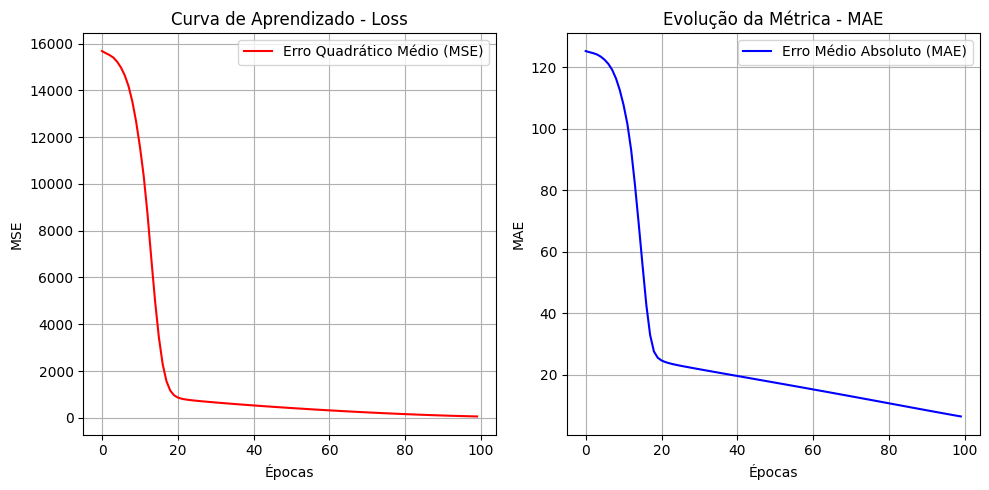

In [20]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [21]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 14.17



Valores Reais para testar previsões

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


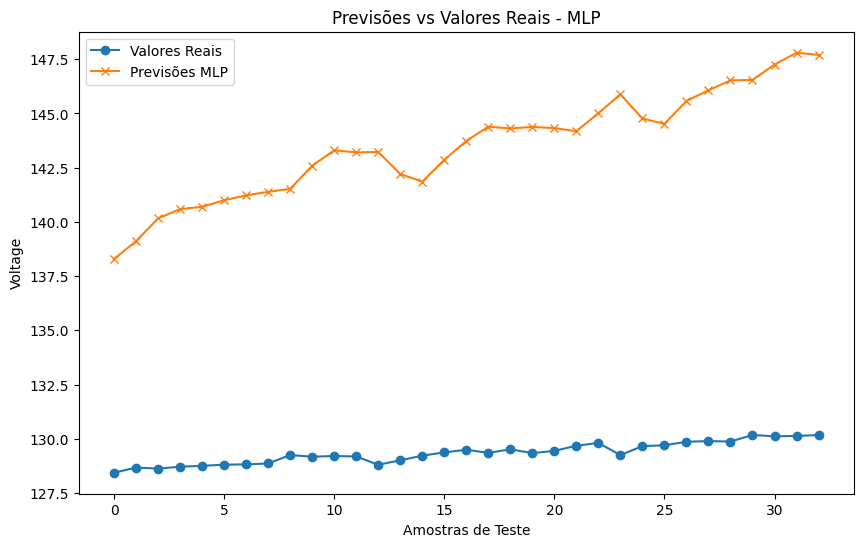

In [22]:
plt.figure(figsize=(10, 6))
y_pred = model_mlp.predict(X_test_scaled)   
plt.plot(y_test, label='Valores Reais', marker='o')
plt.plot(y_pred, label='Previsões MLP', marker='x')
plt.title('Previsões vs Valores Reais - MLP')
plt.xlabel('Amostras de Teste')
plt.ylabel('Voltage')
plt.legend()

MSE:  1831551356633088.0000
RMSE: 42796627.8652
MAE:  15228259.0000



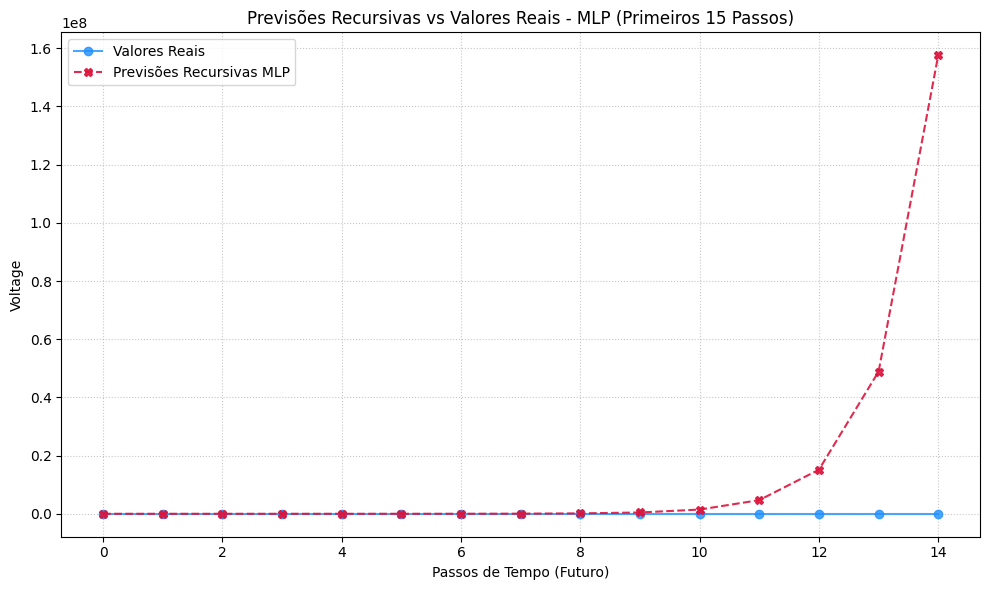

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

current_input = X_test_scaled[0].copy().reshape(1, -1) 
recurrent_prediction = []
n_steps = 15

# Parâmetros do MinMaxScaler para a coluna 0 (shift_1)
min_voltagem = scaler.data_min_[0]
fator_escala = scaler.scale_[0]

for _ in range(n_steps):
    # Previsão da voltagem real
    next_pred = model_mlp.predict(current_input, verbose=0)[0][0]  
    recurrent_prediction.append(next_pred)  
    
    next_pred_scaled = (next_pred - min_voltagem) * fator_escala
    
    current_input = np.roll(current_input, shift=1, axis=1)  
    
    current_input[0, 0] = next_pred_scaled


y_true_50 = y_test[:n_steps].flatten()

mse = mean_squared_error(y_true_50, recurrent_prediction)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_50, recurrent_prediction)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}\n")

plt.figure(figsize=(10, 6))

plt.plot(y_true_50, label='Valores Reais', marker='o', color='dodgerblue', alpha=0.8)
plt.plot(recurrent_prediction, label='Previsões Recursivas MLP', marker='X', color='crimson', linestyle='--', alpha=0.9)

plt.title(f'Previsões Recursivas vs Valores Reais - MLP (Primeiros {n_steps} Passos)')
plt.xlabel('Passos de Tempo (Futuro)')
plt.ylabel('Voltage')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
# SEtar todas as variáveis em um único local como dicionário
